In [14]:
import os
import zipfile
import gdown
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

Подгружаем датасет

In [15]:
import gdown
url = "https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip"
gdown.download(url, "hw_light.zip", quiet=False)

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip
To: /content/hw_light.zip
100%|██████████| 304k/304k [00:00<00:00, 778kB/s]


'hw_light.zip'

Распаковка архива

In [16]:
with zipfile.ZipFile("hw_light.zip", "r") as zip_ref:
    zip_ref.extractall("content")

Загрузка и подготовка тренировочных данных

In [17]:
base_dir = "content/hw_light"

x_train = []
y_train = []

img_height = 20
img_width = 20

for path in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, path)

    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img_array = np.array(img, dtype=np.float32)

            x_train.append(img_array)

            if path == "0":
                y_train.append(0)
            elif path == "1":
                y_train.append(1)
            else:
                y_train.append(2)

x_train = np.array(x_train)
y_train = np.array(y_train)

print("Размер x_train:", x_train.shape)
print("Размер y_train:", y_train.shape)

Размер x_train: (302, 20, 20)
Размер y_train: (302,)


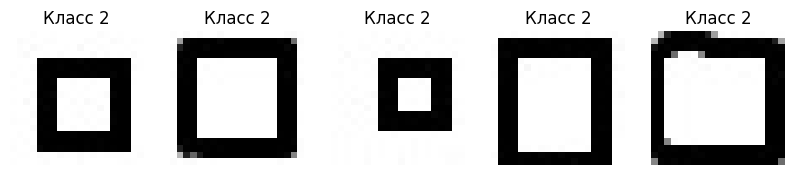

In [18]:
plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Класс {y_train[i]}")
    plt.axis("off")

plt.show()

Нормализация и векторизация признаков

In [19]:
x_train = x_train / 255.0
x_train = x_train.reshape(x_train.shape[0], -1)

print("Новая форма x_train:", x_train.shape)

Новая форма x_train: (302, 400)


Разделение данных на обучающую и тестовую выборки

In [20]:
from sklearn.model_selection import train_test_split

x_train_data, x_test_data, y_train_data, y_test_data = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train:", x_train_data.shape, y_train_data.shape)
print("Test:", x_test_data.shape, y_test_data.shape)

Train: (241, 400) (241,)
Test: (61, 400) (61,)


Определение архитектуры нейросети

In [21]:
class ShapeNet(nn.Module):
    def __init__(self, input_size=400, hidden_size=10, activation_name="relu", num_classes=3):
        super().__init__()

        if activation_name == "relu":
            activation = nn.ReLU()
        elif activation_name == "linear":
            activation = nn.Identity()
        else:
            raise ValueError("activation_name должен быть 'relu' или 'linear'")

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            activation,
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [22]:
import torch

x_train_tensor = torch.tensor(x_train_data, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_data, dtype=torch.long)

x_test_tensor = torch.tensor(x_test_data, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_data, dtype=torch.long)

Функция обучения и оценки модели

In [23]:
def train_and_evaluate(hidden_size, activation_name, batch_size, epochs=20, lr=0.001):
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = ShapeNet(
        input_size=400,
        hidden_size=hidden_size,
        activation_name=activation_name,
        num_classes=3
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = correct / total
    return accuracy

Проведение экспериментов с различными гиперпараметрами

In [24]:
hidden_sizes = [10, 100, 5000]
activation_functions = ["relu", "linear"]
batch_sizes = [10, 100, 1000]

results = []
experiment_number = 1

for hidden_size in hidden_sizes:
    for activation_name in activation_functions:
        for batch_size in batch_sizes:
            accuracy = train_and_evaluate(
                hidden_size=hidden_size,
                activation_name=activation_name,
                batch_size=batch_size,
                epochs=20,
                lr=0.001
            )

            results.append({
                "№": experiment_number,
                "Нейроны": hidden_size,
                "Активация": activation_name,
                "batch_size": batch_size,
                "Точность": round(accuracy * 100, 2)
            })

            print(
                f"Эксперимент {experiment_number}: "
                f"нейроны={hidden_size}, "
                f"активация={activation_name}, "
                f"batch_size={batch_size}, "
                f"точность={accuracy * 100:.2f}%"
            )

            experiment_number += 1

Эксперимент 1: нейроны=10, активация=relu, batch_size=10, точность=80.33%
Эксперимент 2: нейроны=10, активация=relu, batch_size=100, точность=73.77%
Эксперимент 3: нейроны=10, активация=relu, batch_size=1000, точность=65.57%
Эксперимент 4: нейроны=10, активация=linear, batch_size=10, точность=65.57%
Эксперимент 5: нейроны=10, активация=linear, batch_size=100, точность=65.57%
Эксперимент 6: нейроны=10, активация=linear, batch_size=1000, точность=60.66%
Эксперимент 7: нейроны=100, активация=relu, batch_size=10, точность=88.52%
Эксперимент 8: нейроны=100, активация=relu, batch_size=100, точность=80.33%
Эксперимент 9: нейроны=100, активация=relu, batch_size=1000, точность=73.77%
Эксперимент 10: нейроны=100, активация=linear, batch_size=10, точность=70.49%
Эксперимент 11: нейроны=100, активация=linear, batch_size=100, точность=68.85%
Эксперимент 12: нейроны=100, активация=linear, batch_size=1000, точность=68.85%
Эксперимент 13: нейроны=5000, активация=relu, batch_size=10, точность=83.61%
Эк

Таблица сравнения точностей

In [25]:
df_results = pd.DataFrame(results)
df_results

,№,Нейроны,Активация,batch_size,Точность
0,1,10,relu,10,80.33
1,2,10,relu,100,73.77
2,3,10,relu,1000,65.57
3,4,10,linear,10,65.57
4,5,10,linear,100,65.57
5,6,10,linear,1000,60.66
6,7,100,relu,10,88.52
7,8,100,relu,100,80.33
8,9,100,relu,1000,73.77
9,10,100,linear,10,70.49
